The journey from statistical model to useful output has many steps, most of which are taught in other books and courses. The purpose of this book is to focus on one particular aspect of this journey: the development and implementation of statistical algorithms.


It's often nice to think about statistical models and various inferential philosophies and techniques, but when the rubber meets the road, we need an algorithm and a computer program implementation to get the results we need from a combination of our data and our models. This book is about how we fit models to data and the algorithms that we use to do so.

In [1]:
import numpy as np
from scipy import stats, optimize, linalg
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()

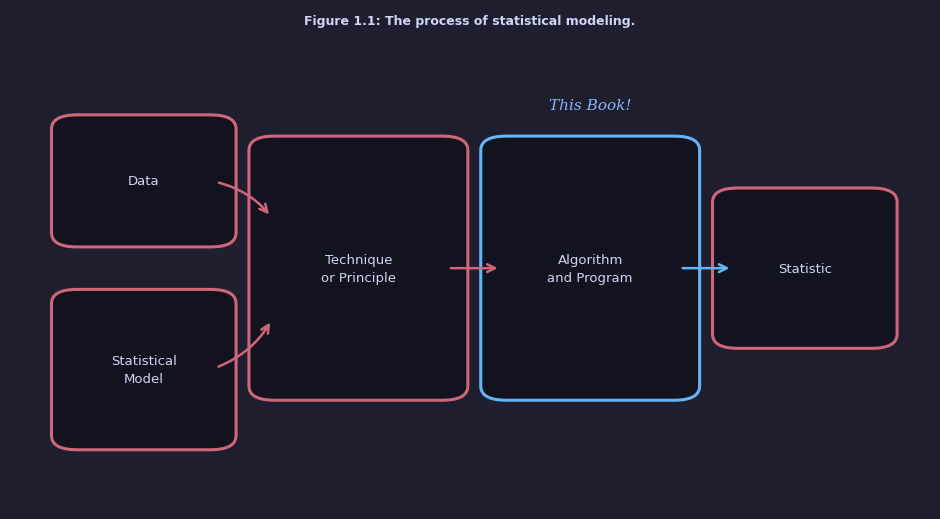

In [2]:
from matplotlib.patches import FancyBboxPatch
BG    = '#1e1e2e'
RED   = '#CF6679'
BLUE  = '#64B5F6'
TEXT  = '#CDD6F4'
ANNOT = '#89B4FA'

fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(-0.02, 1.04)
ax.set_ylim(0, 1)
ax.axis('off')

def _box(cx, cy, w, h, color, label):
    ax.add_patch(FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle="round,pad=0.03", linewidth=2.2,
        edgecolor=color, facecolor='#13131f'))
    ax.text(cx, cy, label, ha='center', va='center',
            color=TEXT, fontsize=9.5, linespacing=1.5)

def _arrow(x0, y0, x1, y1, color=RED, rad=0.0):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.8,
            mutation_scale=14, shrinkA=6, shrinkB=6,
            connectionstyle=f'arc3,rad={rad}'))

_box(0.13, 0.685, 0.155, 0.22, RED,  'Data')
_box(0.13, 0.285, 0.155, 0.28, RED,  'Statistical\nModel')
_box(0.38, 0.50, 0.195, 0.50, RED,  'Technique\nor Principle')
_box(0.65, 0.50, 0.195, 0.50, BLUE, 'Algorithm\nand Program')
_box(0.90, 0.50, 0.155, 0.28, RED,  'Statistic')

_arrow(0.208, 0.685, 0.282, 0.60, RED,  rad=-0.20)
_arrow(0.208, 0.285, 0.282, 0.40, RED,  rad= 0.20)
_arrow(0.478, 0.50, 0.552, 0.50, RED,  rad= 0.0)
_arrow(0.748, 0.50, 0.822, 0.50, BLUE, rad= 0.0)


ax.text(0.65, 0.845, 'This Book!', ha='center', va='center',
        color=ANNOT, fontsize=11, fontstyle='italic', fontfamily='DejaVu Serif')

ax.set_title('Figure 1.1: The process of statistical modeling.',
             color=TEXT, fontsize=9, pad=6, loc='center')
plt.tight_layout()
plt.show()